In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/cleaned_data.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Month,DayOfWeek
0,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,12,1
1,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.6,12,1
2,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,12,1
3,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,30.6,12,1
4,489435,22195,HEART MEASURING SPOONS LARGE,24,2009-12-01 07:46:00,1.65,13085.0,United Kingdom,39.6,12,1


In [2]:
features = df[["Quantity", "Price", "TotalPrice"]]

In [3]:
#scales data from large numbers to (~ -1 to +1 range)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [4]:
#creating clustering model
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_features)

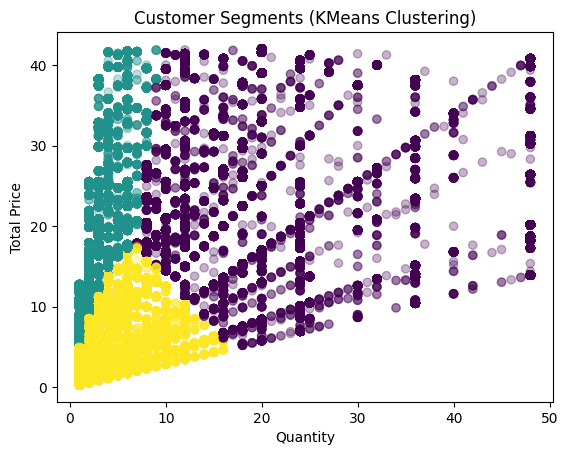

In [5]:
plt.scatter(df["Quantity"], df["TotalPrice"], c=df["Cluster"], alpha=0.3)
plt.xlabel("Quantity")
plt.ylabel("Total Price")
plt.title("Customer Segments (KMeans Clustering)")
plt.show()

In [6]:
df.groupby("Cluster")[["Quantity", "Price", "TotalPrice"]].mean()

,Quantity,Price,TotalPrice
Cluster,,,
0,17.301026,1.390064,20.108235
1,3.410713,6.123999,17.383524
2,4.095550,1.792859,5.596332


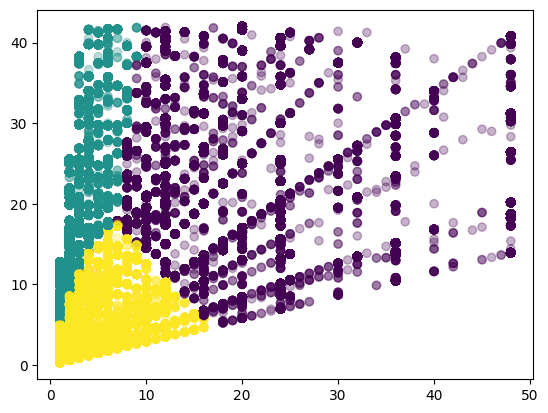

In [7]:
#Removing extreme values (outliers)
filtered = df[df["TotalPrice"] < 1000]
plt.scatter(filtered["Quantity"], filtered["TotalPrice"], c=filtered["Cluster"], alpha=0.3)
plt.show()